In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
from sklearn.metrics import classification_report

## Importar o dataset direto do keras

In [5]:
from tensorflow.keras.datasets import mnist

## Carregamento dos dados

In [6]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

## Ver uma amostra

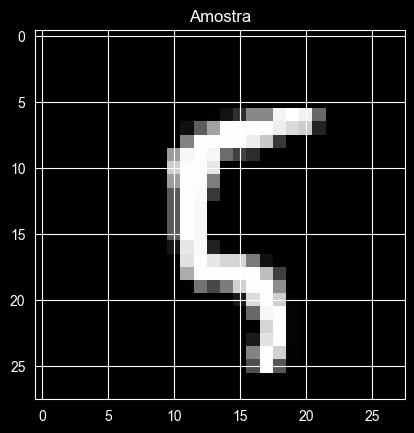

In [7]:
idx = 100
plt.figure()
plt.imshow(x_train[idx], cmap="gray")
plt.title("Amostra")
plt.show()

## Ver a matriz

In [8]:
idx = 300
matriz = x_train[idx].squeeze()
print(matriz)

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 138 238
  217  68   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 150 254 254
  254 232   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0  63 224 254 145
  254 240  22   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0  15 160 253 25

## Pré-processamento

In [9]:
x_train = (x_train.astype("float32")/255.0)[...,None]
x_test = (x_test.astype("float32")/255.0)[...,None]
y_train_oh = tf.keras.utils.to_categorical(y_train,10)
y_test_oh = tf.keras.utils.to_categorical(y_test,10)

## Criação do modelo

In [10]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(16,3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32,3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64,activation="relu"),
    tf.keras.layers.Dense(10,activation="softmax")
])

## Compila definindo o Loss e métrica de avaliação

In [11]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

## Treino da CNN

In [ ]:
history = model.fit(
    x_train, y_train_oh,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=2
)

Epoch 1/10
422/422 - 10s - loss: 0.2918 - accuracy: 0.9139 - val_loss: 0.0835 - val_accuracy: 0.9753 - 10s/epoch - 23ms/step
Epoch 2/10


## Apresentar o resultado do modelo

In [ ]:
plt.plot(history.history["loss"],label="Treino")
plt.plot(history.history["val_loss"],label="TValidação")
plt.legend()

## Salvar Modelo

In [ ]:
model.save("cnn_mnist_model.keras")
#importar o modelo
model = tf.keras.models.load_model("cnn_mnist_model.keras")

## Testar a predição do modelo

In [ ]:
y_pred = np.argmax(model.predict(x_test, verbose = 0), axis = 1)
y_true = y_test

## Métricas de avaliação

In [ ]:
print(classification_report(y_true, y_pred))

## Matriz de confusão

In [ ]:
cm = tf.math.confusion_matrix(y_true, y_pred).numpy()

In [ ]:
print(cm)

# HeatMap da matriz de confusão

In [ ]:
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Classe prevista")
plt.ylabel("Classe Real")
plt.show()